# Lesson 1 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/1/1-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives you a function signature and a docstring stating exactly
what the function must return. Replace the `raise NotImplementedError` with
your implementation. The cell immediately after each task contains
`assert` statements that check your work.

**A failing assert is information, not a grade.** It tells you that the
behaviour does not yet match the contract. Read the assertion message, fix
the function, re-run the cell. There is no penalty for running a cell
twenty times.

The written questions are marked. They are the part of this homework that
carries the learning objective: each one asks you to *run something both
ways and explain the difference*, not to recall a fact. Answers of one
sentence will not be enough; answers of one paragraph, referring to numbers
you actually produced, will.

Every function you need has been demonstrated in `1-practice.ipynb`. Each
task names the section — `see Practice 1 §3.6` — where the relevant material
is. You should not need any other documentation, and you should not need to
search the internet. If you find yourself wanting to, the reference is
probably in the practice notebook and worth finding.

## Before you submit

**Runtime → Restart and run all must complete without error**, with every
assert passing. A notebook that only works because you ran the cells in an
unusual order is not reproducible, and reproducibility is the subject of
§4.1 of the practice notebook.

Then **File → Download → Download .ipynb**, rename the file to
`1-homework-results.ipynb`, and commit it to your fork under
`practice/1/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

Run this first. It is the same configuration cell as the practice notebook.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

SEED = 20250919
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python", sys.version.split()[0], "| numpy", np.__version__)

python 3.13.15 | numpy 2.1.3


## 2. Task 1 — Describe an array

Mechanical. Return the five attributes that describe an array's layout.

*see Practice 1 §3.2*

In [2]:
def describe_array(arr):
    """Return a dict describing the memory layout of `arr`.

    Keys, exactly these five:
        'dtype'    the element type, as a string (use str(...) on the dtype)
        'shape'    the shape, as a tuple
        'ndim'     the number of dimensions, as an int
        'size'     the total number of elements, as an int
        'nbytes'   the total number of bytes occupied by the data, as an int

    No allocation and no copying: read the attributes off `arr`.
    """
    return {
        "dtype": str(arr.dtype),   # dtype — об'єкт numpy.dtype, не рядок; str() перетворює його у формат, який вимагає докстрінг ("int64" тощо)
        "shape": arr.shape,        # вже кортеж (n_rows, n_cols, ...) — повертає як є без перетворень
        "ndim": arr.ndim,          # довжина shape зберігається окремим атрибутом масиву, тому читає його напряму, а не len(arr.shape)
        "size": arr.size,          # добуток усіх елементів shape = кількість ЕЛЕМЕНТІВ, це не те саме, що nbytes
        "nbytes": arr.nbytes,      # size * itemsize; саме через це атрибут задовольняє вимогу "без копіювання" — це метадані масиву, обчислені один раз при створенні, а не прохід по даних
    }

In [3]:
_result = describe_array(np.zeros((3, 4), dtype=np.float64))
assert set(_result) == {"dtype", "shape", "ndim", "size", "nbytes"}, \
    f"expected exactly those five keys, got {sorted(_result)}"
assert _result["shape"] == (3, 4), f"shape wrong: {_result['shape']}"
assert _result["ndim"] == 2, f"ndim wrong: {_result['ndim']}"
assert _result["size"] == 12, f"size wrong: {_result['size']}"
assert _result["nbytes"] == 96, f"nbytes wrong: {_result['nbytes']} (12 elements x 8 bytes)"
assert "float64" in _result["dtype"], f"dtype wrong: {_result['dtype']}"

_int_result = describe_array(np.arange(10, dtype=np.int32))
assert _int_result["nbytes"] == 40, "an int32 array of 10 elements occupies 40 bytes"
assert _int_result["ndim"] == 1

print("Task 1 passed.")

Task 1 passed.


## 3. Task 2 — A view bug, and the fix

The function below is supposed to return a copy of the middle of an array
with its values clipped to zero, leaving the caller's array untouched. It
does not. Find the defect and repair it.

Do not change the signature and do not change what the function returns —
only make it stop modifying its argument.

*see Practice 1 §3.6*

In [4]:
def zero_the_middle(arr, start, stop):
    """Return a NEW array holding arr[start:stop] with every value set to 0.

    `arr` must not be modified. The returned array must have length
    stop - start and must not share memory with `arr`.
    """
    # arr[start:stop] — це VIEW: той самий буфер пам'яті, лише інший offset/довжина,
    # а не нова пам'ять. Якщо занулити view напряму (result[:] = 0 без .copy()),
    # зміна пройде крізь view і зіпсує сам arr — це і була помилка у вихідній версії.
    # .copy() виділяє окрему ділянку пам'яті й переносить туди дані ДО будь-яких змін,
    # тому подальший result[:] = 0 діє вже тільки на копію, а arr лишається недоторканим.
    result = arr[start:stop].copy()
    result[:] = 0
    return result

In [5]:
_original = np.arange(10)
_untouched = np.arange(10)
_returned = zero_the_middle(_original, 3, 6)

assert np.array_equal(_original, _untouched), \
    f"the argument was modified: {_original} should still be {_untouched}"
assert _returned.shape == (3,), f"wrong length: {_returned.shape}"
assert np.all(_returned == 0), f"values not zeroed: {_returned}"
assert not np.shares_memory(_returned, _original), \
    "the result still shares memory with the argument"

print("Task 2 passed.")

Task 2 passed.


## 4. Task 3 — Standardise the columns of a matrix

Applied. Subtract each column's mean and divide by each column's standard
deviation, using broadcasting rather than a loop over columns.

This is what `StandardScaler` does, and Practice 2 §9 will use the
scikit-learn object. Writing it once by hand is the point.

*see Practice 1 §3.7 and §3.8*

In [6]:
def standardise_columns(matrix):
    """Return `matrix` with every column centred and scaled to unit variance.
    ...
    """
    # mean(axis=0) і std(axis=0) згортають вимір 0 (рядки), лишаючи одне число
    # НА КОЖНУ колонку — форма (n_columns,), а не скаляр і не (n_rows,).
    means = matrix.mean(axis=0)
    stds = matrix.std(axis=0, ddof=0)  # ddof=0 = популяційне std (ділення на N), саме дефолт NumPy, як і вимагає умова
    # matrix має форму (n_rows, n_columns); means/stds — (n_columns,).
    # NumPy вирівнює форми з кінця: останній вимір (n_columns) у обох збігається,
    # тому 1D-масив розтягується (broadcast) уздовж вісі рядків і застосовується
    # до кожного стовпця окремо — без явного циклу по колонках.
    return (matrix - means) / stds

In [7]:
_data = np.array([[1.0, 100.0],
                  [2.0, 200.0],
                  [3.0, 300.0],
                  [4.0, 400.0]])
_before = _data.copy()
_scaled = standardise_columns(_data)

assert _scaled.shape == _data.shape, f"shape changed: {_scaled.shape}"
assert np.array_equal(_data, _before), "the input matrix was modified"
assert np.allclose(_scaled.mean(axis=0), 0.0), \
    f"columns not centred, means are {_scaled.mean(axis=0)}"
assert np.allclose(_scaled.std(axis=0), 1.0), \
    f"columns not unit variance, sds are {_scaled.std(axis=0)}"
# The two columns are the same numbers on different scales, so after
# standardising they must be identical.
assert np.allclose(_scaled[:, 0], _scaled[:, 1]), \
    "a linear rescaling of a column should standardise to the same values"

_wide = rng.normal(5.0, 3.0, size=(200, 7))
assert np.allclose(standardise_columns(_wide).mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(standardise_columns(_wide).std(axis=0), 1.0)

print("Task 3 passed.")

Task 3 passed.


## 5. Task 4 — Reductions along an axis

Mechanical, but the axis argument is the thing being tested. Read the
docstring carefully: two of these collapse rows and two collapse columns.

*see Practice 1 §3.8*

In [8]:
def axis_summary(matrix):
    """Return a dict of four reductions of a 2-D array.
    ...
    """
    return {
        # axis=0 "рухається" вздовж рядків і схлопує саме їх -> лишається по одному значенню НА КОЖНУ КОЛОНКУ, форма (n_columns,)
        "per_column_mean": matrix.mean(axis=0),
        # axis=1 "рухається" вздовж колонок і схлопує саме їх -> лишається по одному значенню НА КОЖЕН РЯДОК, форма (n_rows,)
        "per_row_sum": matrix.sum(axis=1),
        "per_row_max": matrix.max(axis=1),
        # sum() без axis згортає ОБИДВА виміри одразу -> результат 0-вимірний numpy-скаляр; float(...) явно переводить його у звичайний python float,
        # як і вимагає умова ("scalar float", а не 0-d ndarray)
        "grand_total": float(matrix.sum()),
    }

In [9]:
_grid = np.array([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
_summary = axis_summary(_grid)

assert _summary["per_column_mean"].shape == (3,), \
    f"per_column_mean should have one value per column: {_summary['per_column_mean'].shape}"
assert np.allclose(_summary["per_column_mean"], [2.5, 3.5, 4.5])
assert _summary["per_row_sum"].shape == (2,), \
    f"per_row_sum should have one value per row: {_summary['per_row_sum'].shape}"
assert np.allclose(_summary["per_row_sum"], [6.0, 15.0])
assert np.allclose(_summary["per_row_max"], [3.0, 6.0])
assert np.isclose(_summary["grand_total"], 21.0)

# A non-square array catches an axis swapped by accident.
_tall = rng.normal(size=(50, 4))
_tall_summary = axis_summary(_tall)
assert _tall_summary["per_column_mean"].shape == (4,)
assert _tall_summary["per_row_sum"].shape == (50,)

print("Task 4 passed.")

Task 4 passed.


### Question 1 — the axis argument

Take the `(50, 4)` array `_tall` from the cell above. Compute `_tall.sum()`,
`_tall.sum(axis=0)` and `_tall.sum(axis=1)`, and print the shape of each.

Explain, in your own words, **why `axis=0` produces four numbers and not
fifty**, given that the array has fifty rows. Then state which of the three
you would use to answer the question "what is the average value of each
feature across all samples", and why.

In [10]:
total = _tall.sum()
per_column = _tall.sum(axis=0)
per_row = _tall.sum(axis=1)

print("_tall.sum()          :", total, "      shape:", total.shape)
print("_tall.sum(axis=0)    :", per_column, "shape:", per_column.shape)
print("_tall.sum(axis=1)[:5]:", per_row[:5], "... shape:", per_row.shape)

_tall.sum()          : -9.792221026356906       shape: ()
_tall.sum(axis=0)    : [-8.02177989 -0.81004707  8.21145867 -9.17185273] shape: (4,)
_tall.sum(axis=1)[:5]: [-0.50510624 -2.09015697  0.15802573  0.22961949 -0.40134908] ... shape: (50,)


**Your answer:**

Вивід вище: `_tall.sum()` повертає одне число (−9.79) з формою `()`, `_tall.sum(axis=0)` — чотири числа `[-8.02, -0.81, 8.21, -9.17]` з формою `(4,)`, а `_tall.sum(axis=1)` — п'ятдесят чисел з формою `(50,)`.

`axis=0` позначає вимір, який **згортається**, а не той, що лишається в результаті. `_tall` має форму (50, 4): вісь 0 — рядки (50 зразків), вісь 1 — колонки (4 ознаки). `sum(axis=0)` підсумовує всі 50 рядків окремо для кожної колонки, тому вимір довжиною 50 зникає, а лишається вимір довжиною 4 — по одній сумі на ознаку. `sum(axis=1)` робить навпаки: згортає 4 колонки в кожному рядку й лишає 50 чисел — по одному на зразок. Спокуса прочитати `axis=0` як «дай по числу на кожен рядок» виникає саме тому, що вісь 0 — це вісь рядків; але аргумент каже numpy, яку вісь усунути, а не яку зберегти.

Для питання «яке середнє значення кожної ознаки по всіх зразках» потрібне одне число на ознаку, тобто згорнути треба вимір зразків — `_tall.mean(axis=0)`, результат форми `(4,)`.

## 6. Task 5 — Outliers by the k-sigma rule

Applied. Generalise the practice notebook's 3σ filter to an arbitrary threshold.

*see Practice 1 §3.9 and §4.7*

In [11]:
def sigma_outliers(sample, k=3.0):
    """Flag the values of `sample` that lie more than k standard deviations
    from the sample mean.
    ...
    """
    mean = sample.mean()       # середнє САМОЇ вибірки, а не якесь припущене число,
                                # як і вимагає умова
    std = sample.std(ddof=0)   # ddof=0 — популяційне std, дефолт NumPy (ділення на N)

    # |x - mean| > k*std — векторизоване порівняння: numpy застосовує його одразу
    # до КОЖНОГО елемента sample (broadcasting скаляра проти масиву), без циклу.
    # np.abs обов'язковий, бо викид може лежати як вище, так і нижче середнього —
    # інакше пропустили б аномально малі значення.
    mask = np.abs(sample - mean) > k * std

    # mask — булевий масив тієї самої форми, що й sample; sample[mask] — це
    # "boolean indexing": numpy бере лише ті елементи, де mask == True,
    # і зберігає їхній вихідний порядок автоматично.
    values = sample[mask]

    return mask, values

In [12]:
_plain = np.array([1.0, 2.0, 3.0, 2.0, 1.0, 50.0])
_mask, _values = sigma_outliers(_plain, k=2.0)

assert _mask.dtype == bool, f"mask must be boolean, got {_mask.dtype}"
assert _mask.shape == _plain.shape, f"mask shape {_mask.shape} != sample shape {_plain.shape}"
assert _mask.sum() == 1, f"expected exactly one outlier at k=2, found {_mask.sum()}"
assert np.allclose(_values, [50.0]), f"wrong value flagged: {_values}"

# On a clean normal sample the 3-sigma rule should flag very few points.
_normal = rng.normal(0.0, 1.0, 10_000)
_normal_mask, _ = sigma_outliers(_normal, k=3.0)
_rate = _normal_mask.mean()
assert 0.0 < _rate < 0.01, \
    f"flag rate {_rate:.4f} is implausible for 3 sigma on normal data (expect ~0.0027)"

# A larger threshold can never flag more points than a smaller one.
assert sigma_outliers(_normal, k=4.0)[0].sum() <= _normal_mask.sum()

print(f"Task 5 passed. 3-sigma flag rate on 10,000 normal draws: {_rate:.4%}")

Task 5 passed. 3-sigma flag rate on 10,000 normal draws: 0.3100%


### Question 2 — the threshold is a choice

Using the 10 000-point normal sample `_normal`, run `sigma_outliers` at
`k = 1, 2, 3, 4, 5` and print the number of points flagged at each.

Then answer: the theoretical fractions outside k standard deviations of a
normal distribution are about 32 %, 4.6 %, 0.27 %, 0.0063 % and 0.000057 %.
Compare your counts with those. **At which k does the sample stop having
enough data to estimate the rate at all**, and what does that imply about
using a very large k to define an outlier?

Finally: none of the points in `_normal` is an error — they all came from
the same generator. Describe one concrete situation in which you *would* be
justified in deleting a flagged point, and say what evidence would justify
it.

In [13]:
for k in (1, 2, 3, 4, 5):
    mask, values = sigma_outliers(_normal, k=k)
    print(f"k={k}: flagged {mask.sum():>5} out of {len(_normal)}  ({100 * mask.mean():.4f}%)")

k=1: flagged  3163 out of 10000  (31.6300%)
k=2: flagged   454 out of 10000  (4.5400%)
k=3: flagged    31 out of 10000  (0.3100%)
k=4: flagged     2 out of 10000  (0.0200%)
k=5: flagged     0 out of 10000  (0.0000%)


**Your answer:**

Мої підрахунки на 10 000 точках `_normal` проти теоретичних очікувань:

| k | позначено | частка | теорія | очікувана кількість |
|---|---|---|---|---|
| 1 | 3163 | 31.63% | ≈32% | ≈3170 |
| 2 | 454 | 4.54% | ≈4.6% | ≈455 |
| 3 | 31 | 0.31% | ≈0.27% | ≈27 |
| 4 | 2 | 0.02% | ≈0.0063% | ≈0.63 |
| 5 | 0 | 0% | ≈0.000057% | ≈0.0057 |

Для k = 1, 2, 3 спостереження збігаються з теорією в межах випадкового шуму. Похибка підрахунку рідкісних подій — приблизно √(очікувана кількість): при k=3 очікується ≈27 ± 5, і мої 31 точка — в межах одного такого відхилення. Відносна похибка ще прийнятна (≈19%).

Вибірка перестає оцінювати частку на **k = 4**. Там очікується менше однієї точки (0.63) на всю вибірку, а я отримав 2 — частка 0.02% утричі більша за справжню 0.0063%. Це не означає, що генератор зламаний: коли очікується менше однієї події, результат — це по суті вибір між 0, 1 чи 2 точками, і кожна точка змінює оцінену частку в рази. На k = 5 вийшло 0 точок. Щоб побачити в середньому хоч одну, потрібно близько 1.75 млн спостережень. Тож «0» тут означає не «таких значень не буває», а «вибірка замала, щоб це виміряти». Висновок щодо великих k: поріг, для якого на наявному обсязі даних очікується менше однієї точки, нічого не вимірює. Правило з таким порогом не виявляє викидів, а просто майже ніколи не спрацьовує, і за відсутністю позначених точок не можна відрізнити «даних достатньо, викидів немає» від «даних замало».

Жодна точка `_normal` не є помилкою — усі вони з того самого генератора, тож 3σ-правило ловить тут рідкісні, але цілком легітимні значення. Видаляти позначену точку виправдано лише тоді, коли є **незалежний від статистики доказ**, що механізм вимірювання в цей момент був несправний. Конкретний приклад: датчик температури при обриві контакту записує код −999 °C. Підставою для видалення тут є не відстань у сигмах, а зовнішні свідчення: журнал пристрою фіксує обрив зв'язку в той самий момент, значення фізично неможливе, і та сама константа −999 повторюється в інших збоях. Без такого доказу точка, далека від середнього, — це дані, а не помилка.

## 7. Task 6 — A NaN-aware mean, written by hand

Mechanical. Do not call `np.nanmean`; the point is to build it from the
masking tools.

*see Practice 1 §3.9 and §3.10*

In [14]:
def mean_ignoring_nan(sample):
    """Return the mean of the non-missing values of `sample`.
    ...
    """
    valid = ~np.isnan(sample)   # булева маска: True там, де значення НЕ пропущене (NaN)
    if not valid.any():         # усі значення NaN -> валідних немає, явно повертаємо np.nan,
                                 # інакше sample[valid] був би порожнім масивом і .mean()
                                 # видав би RuntimeWarning + np.nan сам по собі, але неявно
        return np.nan
    return sample[valid].mean() # sample[valid] — лише невідкинуті значення (boolean indexing),
                                 # серед них NaN вже немає, тому звичайний .mean() рахує чесно,
                                 # без будь-якої nan-обізнаної редукції на кшталт np.nanmean

In [15]:
assert np.isclose(mean_ignoring_nan(np.array([1.0, 2.0, np.nan, 4.0])), 7.0 / 3.0)
assert np.isclose(mean_ignoring_nan(np.array([5.0, 5.0, 5.0])), 5.0)
assert np.isnan(mean_ignoring_nan(np.array([np.nan, np.nan]))), \
    "an all-missing sample has no mean; return np.nan"

_with_gaps = rng.normal(0.0, 1.0, 1000)
_with_gaps[rng.choice(1000, size=100, replace=False)] = np.nan
assert np.isclose(mean_ignoring_nan(_with_gaps), np.nanmean(_with_gaps)), \
    "your result should agree with np.nanmean"
assert np.isnan(_with_gaps.mean()), \
    "sanity check: the plain mean of an array containing NaN is NaN"

print("Task 6 passed.")

Task 6 passed.


## 8. Task 7 — How well does a sample know its own distribution

Applied. Draw samples of increasing size from a known normal distribution
and measure how far the estimated parameters fall from the true ones.

*see Practice 1 §4.1 and §4.6*

In [16]:
def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Estimate mu and sigma from samples of several sizes.
    ...
    """
    mu_hats = []
    sigma_hats = []
    for n in sizes:                                      # у заданому порядку, і кожен розмір
                                                           # бере дані з ТОГО САМОГО generator
        sample = generator.normal(true_mu, true_sigma, size=n)
        # кожен виклик .normal() просуває внутрішній стан generator вперед; тому для n=20
        # беруться перші 20 чисел потоку, а для наступного n — вже НАСТУПНІ, а не ті самі.
        # Саме тому важливо не створювати новий generator на кожній ітерації і не змінювати
        # порядок sizes — інакше при фіксованому seed результат більше не відтворюється.
        mu_hats.append(sample.mean())
        sigma_hats.append(sample.std(ddof=1))             # ddof=1 -> НЕЗМІЩЕНА оцінка std:
                                                           # ділення на (n-1), а не на n,
                                                           # як явно вимагає докстрінг

    return {
        "n": np.array(sizes),
        "mu_hat": np.array(mu_hats),
        "sigma_hat": np.array(sigma_hats),
    }

In [17]:
_sizes = [10, 100, 1_000, 10_000, 100_000]
_recovered = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))

assert set(_recovered) == {"n", "mu_hat", "sigma_hat"}
assert len(_recovered["mu_hat"]) == len(_sizes)
assert np.array_equal(_recovered["n"], np.array(_sizes))

# Reproducible: the same seed must give the same estimates.
_again = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))
assert np.allclose(_recovered["mu_hat"], _again["mu_hat"]), \
    "same seed gave different answers; are you drawing from the generator you were passed?"

# The largest sample must land close to the truth.
assert abs(_recovered["mu_hat"][-1] - 2.0) < 0.1, \
    f"mu estimate from 100,000 draws is {_recovered['mu_hat'][-1]:.4f}, expected near 2.0"
assert abs(_recovered["sigma_hat"][-1] - 5.0) < 0.1, \
    f"sigma estimate from 100,000 draws is {_recovered['sigma_hat'][-1]:.4f}, expected near 5.0"

# and the error should shrink as n grows
_err_small = abs(_recovered["mu_hat"][0] - 2.0)
_err_large = abs(_recovered["mu_hat"][-1] - 2.0)
assert _err_large < _err_small, "the estimate should improve with more data"

for n, mu, sd in zip(_recovered["n"], _recovered["mu_hat"], _recovered["sigma_hat"]):
    print(f"n = {n:7,}   mu_hat = {mu:8.4f}   sigma_hat = {sd:8.4f}")
print("\nTask 7 passed.")

n =      10   mu_hat =   2.4234   sigma_hat =   3.9067
n =     100   mu_hat =   2.2577   sigma_hat =   4.9827
n =   1,000   mu_hat =   1.7686   sigma_hat =   4.9318
n =  10,000   mu_hat =   2.0434   sigma_hat =   5.0002
n = 100,000   mu_hat =   1.9896   sigma_hat =   5.0035

Task 7 passed.


### Question 3 — the seed and the sample size

Two experiments.

**(a)** Call `recover_parameters(2.0, 5.0, [100], ...)` with five *different*
seeds. Record the five estimates of mu. How much do they vary?

**(b)** Call it with a single fixed seed but sizes `[100, 10_000]`. How far
is each estimate from 2.0?

Now explain the distinction these two experiments draw out. **The seed
controls one thing and the sample size controls a different thing — name
both.** In particular: does a larger seed give a better answer? Does
re-running with a new seed tell you anything you did not know? And if your
estimate at n = 100 is off by 0.4, is that a bug?

Use the error at n = 100 and at n = 10 000 to estimate how the error scales
with n, and compare it with the square-root rule from Practice 1 §4.6.

In [18]:
# (a) — п'ять різних seed, той самий n=100: наскільки розкидані оцінки mu?
mu_by_seed = []
for seed in range(5):
    gen = np.random.default_rng(seed)
    result = recover_parameters(2.0, 5.0, [100], gen)
    mu_by_seed.append(result["mu_hat"][0])
    print(f"seed={seed}: mu_hat={result['mu_hat'][0]:.4f}   |error|={abs(result['mu_hat'][0] - 2.0):.4f}")

mu_by_seed = np.array(mu_by_seed)
print("\nрозкид: min", mu_by_seed.min(), " max", mu_by_seed.max(),
      " std by seed", mu_by_seed.std())

# (b) — один фіксований seed, два розміри вибірки: наскільки оцінка наближається до 2.0?
gen = np.random.default_rng(0)
result = recover_parameters(2.0, 5.0, [100, 10_000], gen)
for n, mu_hat in zip(result["n"], result["mu_hat"]):
    print(f"n={n:>6}: mu_hat={mu_hat:.4f}   |error|={abs(mu_hat - 2.0):.4f}")

seed=0: mu_hat=2.4055   |error|=0.4055
seed=1: mu_hat=1.6319   |error|=0.3681
seed=2: mu_hat=1.9579   |error|=0.0421
seed=3: mu_hat=1.6911   |error|=0.3089
seed=4: mu_hat=1.6835   |error|=0.3165

розкид: min 1.6319393936352646  max 2.4054834674535774  std by seed 0.28908075921823073
n=   100: mu_hat=2.4055   |error|=0.4055
n= 10000: mu_hat=2.0219   |error|=0.0219


**Your answer:**

**Що показали числа.** (a) При n = 100 п'ять різних seed дали оцінки μ від 1.63 до 2.41 (стандартне відхилення між ними ≈0.29). Похибки: 0.41, 0.37, 0.04, 0.31, 0.32. (b) З одним seed=0 похибка при n = 100 дорівнює 0.4055, а при n = 10 000 — 0.0219.

**Seed** керує тим, яку саме з усіх можливих вибірок цього розміру я отримую, — тобто конкретною реалізацією шуму. **Розмір вибірки** керує тим, скільки інформації містить оцінка, тобто наскільки близько до істинного параметра вона буде в середньому. Більший seed не дає кращої відповіді: у значень seed немає порядку «якості». У (a) seed=2 випадково дав найточнішу оцінку (1.96), а seed=0 — найгіршу (2.41), і з цього нічого не випливає. Перезапуск з новим seed не дає нової інформації про μ — це ще одна реалізація того самого шуму при тому самому n. Єдина користь — побачити масштаб цього шуму.

Відхилення на 0.4 при n = 100 — не баг. Стандартна похибка середнього σ/√n = 5/√100 = 0.5. Моє відхилення 0.41 менше за одну стандартну похибку, а розкид між seed (≈0.29) того самого порядку, що й 0.5 (з п'яти значень його не оцінити точніше).

**Масштабування з n.** Правило квадратного кореня (Practice 1 §4.6) передбачає, що при збільшенні n у 100 разів похибка має зменшитися в √100 = 10 разів. У мене відношення 0.4055 / 0.0219 ≈ 18.5. Порядок той самий, але число не рівно 10, бо кожне з двох значень — це одна випадкова похибка, а не середня. При n = 100 мені дісталося відхилення ≈0.8 стандартної похибки (0.41 / 0.5), а при n = 10 000 — ≈0.4 (0.0219 / 0.05). Правило 1/√n описує типову похибку, а одна пара вимірів її лише приблизно ілюструє. Практичний висновок: щоб зменшити похибку вдесятеро, потрібно в сто разів більше даних.

## 9. Task 8 — Build a correlated cloud

Applied. Construct a 2-D Gaussian sample with a specified correlation, and
confirm you got what you asked for.

*see Practice 1 §4.9*

In [19]:
def correlated_cloud(sd_x, sd_y, correlation, n, generator):
    """Draw `n` points from a 2-D normal centred at the origin with the given
    marginal standard deviations and correlation.
    ...
    """
    # діагональ — дисперсії (sd^2) кожної осі окремо; позадіагональні елементи —
    # коваріація, виражена через кореляцію: cov(x,y) = correlation * sd_x * sd_y.
    # Матриця симетрична (елемент [0,1] дорівнює [1,0]) — це обов'язкова властивість
    # будь-якої коваріаційної матриці.
    covariance = np.array([
        [sd_x**2,                   correlation * sd_x * sd_y],
        [correlation * sd_x * sd_y, sd_y**2],
    ])

    # центр хмари — початок координат [0, 0], а форма/нахил хмари повністю
    # визначається covariance; multivariate_normal сам розкладає її (через
    # Холецького), щоб згенерувати корельовані x та y з одного потоку generator
    points = generator.multivariate_normal(mean=[0.0, 0.0], cov=covariance, size=n)

    return points, covariance

In [20]:
_points, _cov = correlated_cloud(3.0, 3.0, 0.8, 20_000, np.random.default_rng(1))

assert _points.shape == (20_000, 2), f"wrong shape: {_points.shape}"
assert _cov.shape == (2, 2)
assert np.isclose(_cov[0, 0], 9.0), f"variance of x should be sd_x**2 = 9, got {_cov[0, 0]}"
assert np.isclose(_cov[0, 1], _cov[1, 0]), "a covariance matrix is symmetric"
assert np.isclose(_cov[0, 1], 7.2), f"off-diagonal should be 0.8*3*3 = 7.2, got {_cov[0, 1]}"

_measured = np.corrcoef(_points.T)[0, 1]
assert abs(_measured - 0.8) < 0.02, \
    f"the sample correlation is {_measured:.4f}, expected close to 0.8"

# a zero correlation must give an axis-aligned cloud
_indep, _ = correlated_cloud(2.0, 5.0, 0.0, 20_000, np.random.default_rng(2))
assert abs(np.corrcoef(_indep.T)[0, 1]) < 0.03

print(f"Task 8 passed. Measured correlation {_measured:.4f} against a requested 0.8.")

Task 8 passed. Measured correlation 0.7963 against a requested 0.8.


## 10. Task 9 — A figure that can be read without its caption

Applied. Draw the two clouds side by side, correctly labelled.

Requirements, all of which the assert checks:

- one `Figure` with two `Axes`, side by side
- left panel: correlation 0.0; right panel: correlation 0.9
- both panels: an x label, a y label, a title, and equal aspect
- a title on the figure as a whole

*see Practice 1 §4.9 and §5*

In [21]:
def compare_correlations(generator):
    """Draw two 2-D clouds side by side and return (fig, axes).
    ...
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # OO-інтерфейс: одразу отримуємо
                                                        # fig і масив із двох Axes, без
                                                        # неявного pyplot-стану

    correlations = (0.0, 0.9)
    for ax, correlation in zip(axes, correlations):
        # той самий generator передається в обидва виклики: перша хмара забирає
        # перші 2000*2 випадкових числа з потоку, друга — наступні; це узгоджено
        # з тим, як передається generator у recover_parameters (Task 7) —
        # відтворюваність залежить від порядку викликів, а не від нового seed щоразу
        points, _ = correlated_cloud(2.0, 2.0, correlation, 2000, generator)

        ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.4)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"correlation = {correlation}")
        ax.set_aspect("equal")  # однаковий масштаб по обох осях — інакше нахил хмари
                                  # від correlation=0.9 буде спотворений розтягом Axes
                                  # і візуально виглядатиме менш витягнутим, ніж є

    fig.suptitle("Вплив кореляції на форму 2-D нормальної хмари точок")
    return fig, axes

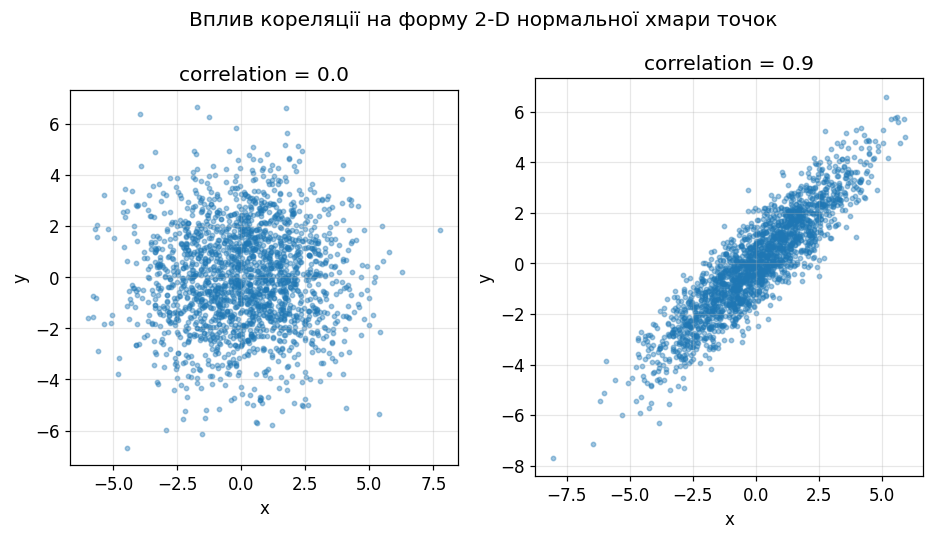

Task 9 passed.


In [22]:
_fig, _axes = compare_correlations(np.random.default_rng(3))

assert len(_axes) == 2, f"expected two Axes, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_aspect() == 1.0, f"panel {_i} does not have equal aspect"
    assert len(_ax.collections) > 0, f"panel {_i} has nothing plotted on it"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), \
    "the figure has no suptitle"

plt.show()
print("Task 9 passed.")

### Question 4 — the off-diagonal entry

Re-run `compare_correlations` mentally, or actually, with the right-hand
correlation set to **-0.9** instead of `0.9`.

Describe what changes in the picture and what does **not**. Specifically:
does the spread of `x` alone change? Does the spread of `y` alone change?
What would you see if you plotted a histogram of just the `x` coordinate
for correlation `0.0`, `0.9` and `-0.9` — could you tell the three cases
apart from that histogram?

Then state the consequence in one sentence: what does this say about
inspecting variables one at a time?

correlation=+0.0:  std(x)=1.996  std(y)=2.028  вибіркова corr=-0.003
correlation=+0.9:  std(x)=2.010  std(y)=1.996  вибіркова corr=+0.904
correlation=-0.9:  std(x)=2.005  std(y)=2.011  вибіркова corr=-0.894


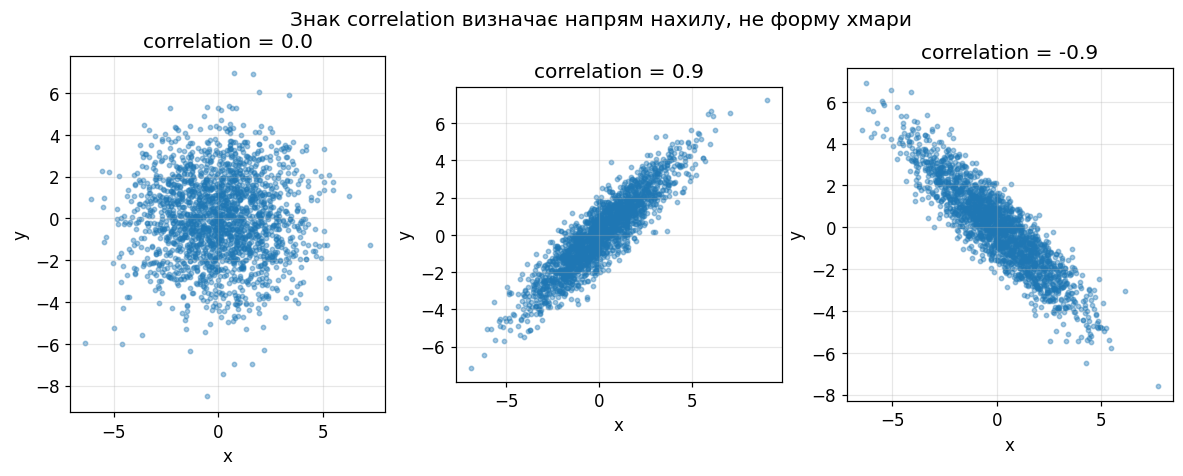

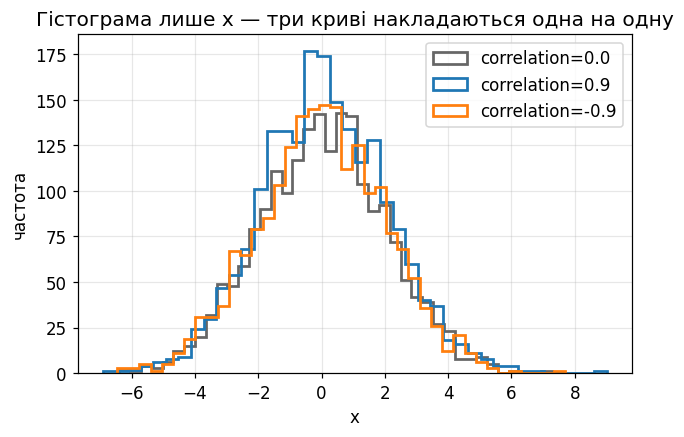

In [23]:
demo_gen = np.random.default_rng(SEED)

# три хмари поруч: 0.0, 0.9 і тепер ще -0.9
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
correlations = (0.0, 0.9, -0.9)
for ax, correlation in zip(axes, correlations):
    points, _ = correlated_cloud(2.0, 2.0, correlation, 2000, demo_gen)
    # числа, на які спирається відповідь: розкид кожної координати окремо і їхня спільна кореляція
    print(f"correlation={correlation:+.1f}:  std(x)={points[:, 0].std():.3f}  "
          f"std(y)={points[:, 1].std():.3f}  вибіркова corr={np.corrcoef(points.T)[0, 1]:+.3f}")
    ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.4)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"correlation = {correlation}")
    ax.set_aspect("equal")
fig.suptitle("Знак correlation визначає напрям нахилу, не форму хмари")

# окремо - лише МАРГІНАЛЬНИЙ розподіл x для всіх трьох випадків
fig2, ax2 = plt.subplots(figsize=(6.5, 4))
hist_gen = np.random.default_rng(SEED)
for correlation, color in zip(correlations, ("0.4", "tab:blue", "tab:orange")):
    points, _ = correlated_cloud(2.0, 2.0, correlation, 2000, hist_gen)
    ax2.hist(points[:, 0], bins=40, histtype="step", linewidth=1.8,
              label=f"correlation={correlation}", color=color)
ax2.set_xlabel("x")
ax2.set_ylabel("частота")
ax2.set_title("Гістограма лише x — три криві накладаються одна на одну")
ax2.legend()
plt.show()

**Your answer:**

Вивід вище: при correlation = 0.0, +0.9 і −0.9 стандартні відхилення x дорівнюють 1.996, 2.010 і 2.005, а y — 2.028, 1.996 і 2.011, тобто в усіх трьох випадках ≈2.0 (як задано: sd_x = sd_y = 2.0). Змінюється лише вибіркова кореляція: −0.003, +0.904 і −0.894.

При correlation = −0.9 хмара витягується вздовж протилежної діагоналі: «\» замість «/». Великим x тепер відповідають малі y. Це дзеркальне відображення тієї самої еліптичної форми, а не інша форма.

Розкид x окремо не змінюється, і розкид y окремо теж — це підтверджують числа вище. Кореляція задає лише те, як x і y рухаються разом, а не ширину кожної з них. Гістограми самої координати x для 0.0, 0.9 і −0.9 (другий графік) лягають одна на одну: у кожному випадку це той самий N(0, 2²). Відрізнити три випадки за такою гістограмою неможливо, бо кореляція — властивість спільного розподілу, в одновимірному маргінальному розподілі її немає.

Висновок в одне речення: перегляд змінних поодинці (окремі гістограми, середні, std) сліпий до залежностей між ними, тож зв'язок видно лише на спільному розподілі — scatter-плоті, коваріації чи кореляції.

## 11. Task 10 — Histograms and the bin count

Applied. Draw one sample three ways and decide which picture to trust.

*see Practice 1 §4.5*

In [24]:
def histogram_grid(sample, bin_counts, density):
    """Plot `sample` as a histogram once per entry in `bin_counts`.
    ...
    """
    n_panels = len(bin_counts)
    fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4))

    # при n_panels == 1 plt.subplots повертає ОДИНОЧНИЙ Axes, а не масив з одного
    # елемента — без цієї обгортки zip(axes, bin_counts) впав би або пройшовся
    # по внутрішніх об'єктах Axes, а не по самому Axes
    if n_panels == 1:
        axes = np.array([axes])

    # density=True дає щільність ймовірності (площа під гістограмою = 1, вісь у
    # інших одиницях), density=False дає сирі лічильники — це різні величини,
    # тому підпис осі y мусить називати саме те, що на ній зображено
    y_label = "density" if density else "count"

    for ax, bins in zip(axes, bin_counts):
        ax.hist(sample, bins=bins, density=density)
        ax.set_xlabel("value")
        ax.set_ylabel(y_label)
        ax.set_title(f"bins={bins}")

    return fig, axes

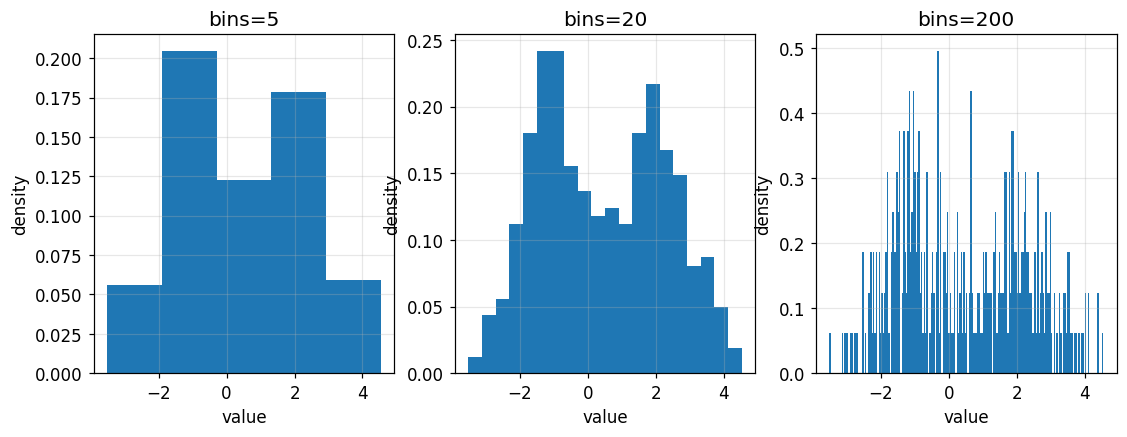

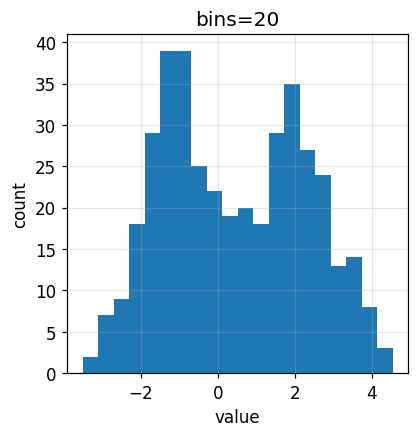

Task 10 passed.


In [25]:
# A deliberately awkward sample: two overlapping normals, 400 points.
_mixture = np.concatenate([
    np.random.default_rng(7).normal(-1.0, 1.0, 200),
    np.random.default_rng(8).normal(2.0, 1.0, 200),
])

_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=True)

assert len(_axes) == 3, f"expected three panels, got {len(_axes)}"
for _ax in _axes:
    assert _ax.get_xlabel(), "a panel has no x label"
    assert _ax.get_ylabel() == "density", \
        f"with density=True the y axis is a density, not a {_ax.get_ylabel()!r}"
    assert _ax.get_title(), "a panel has no title"
    assert len(_ax.patches) > 0, "a panel has no bars"

_fig_count, _axes_count = histogram_grid(_mixture, [20], density=False)
assert _axes_count[0].get_ylabel() == "count"

plt.show()
print("Task 10 passed.")

### Question 5 — bin count and density

Look at the three panels you just produced from `_mixture`, which was built
from **two** normal components centred at -1 and +2.

**(a)** At which bin count is the two-component structure visible? At which
is it hidden? At 200 bins, are the peaks you see real?

**(b)** Re-run `histogram_grid(_mixture, [5, 20, 200], density=False)` and
compare the y axes with the `density=True` version. The shapes are
identical but the numbers are not. Explain what `density=True` divides by,
and why that makes two samples **of different sizes** comparable on one
axis where raw counts would not be.

**(c)** A colleague shows you a histogram with a clear double peak and
concludes the population has two subgroups. What is the first question you
ask them?

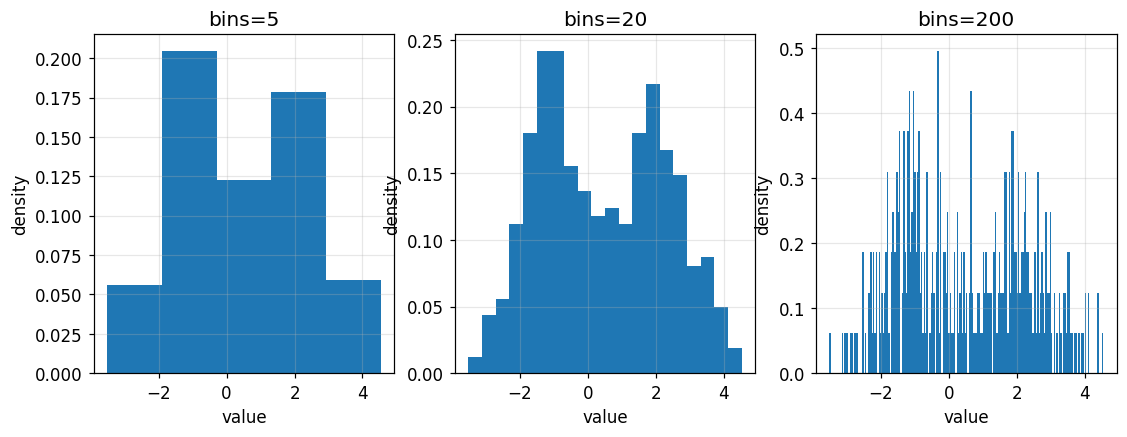

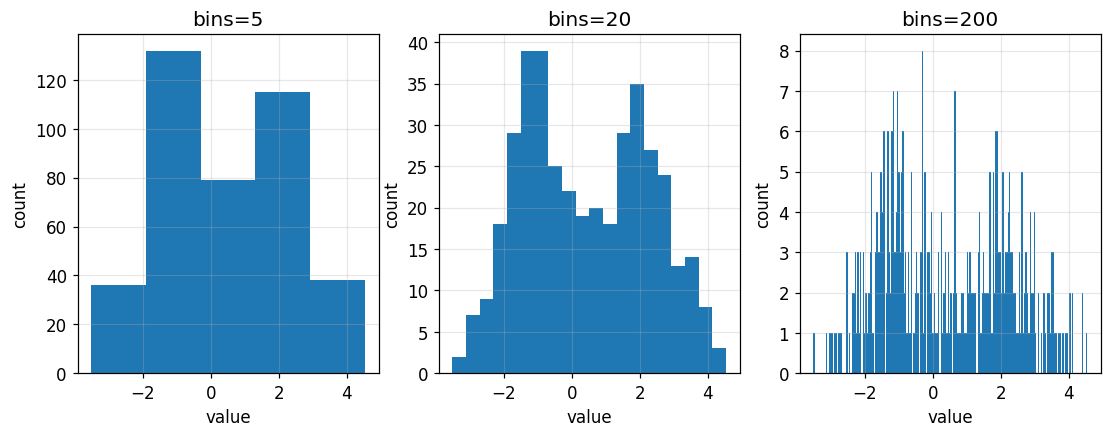

bins=  5: max count=132  max density=0.2048  count/(N*width)=0.2048  площа density=1.000
bins= 20: max count= 39  max density=0.2421  count/(N*width)=0.2421  площа density=1.000
bins=200: max count=  8  max density=0.4966  count/(N*width)=0.4966  площа density=1.000
висоти 5 бінів (density): [0.056 0.205 0.123 0.178 0.059]


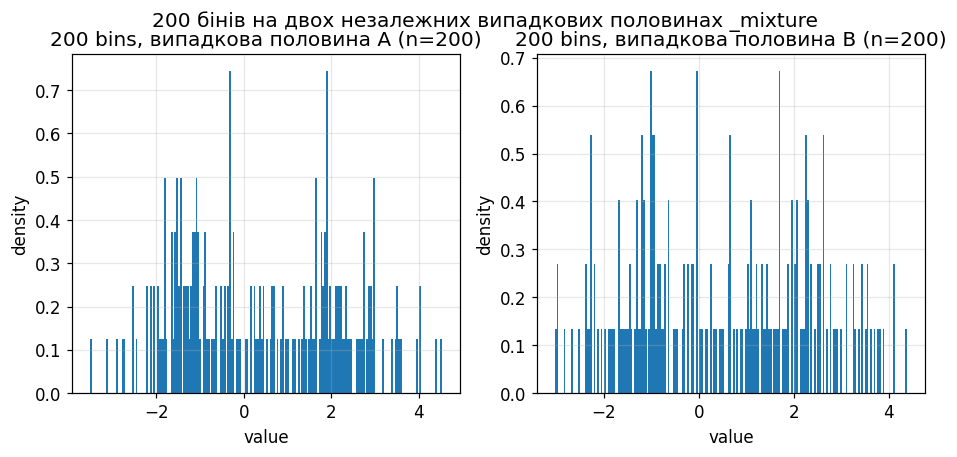

bins=200: кореляція висот стовпчиків між половинами = 0.144, порожніх бінів у половині A: 83 з 200


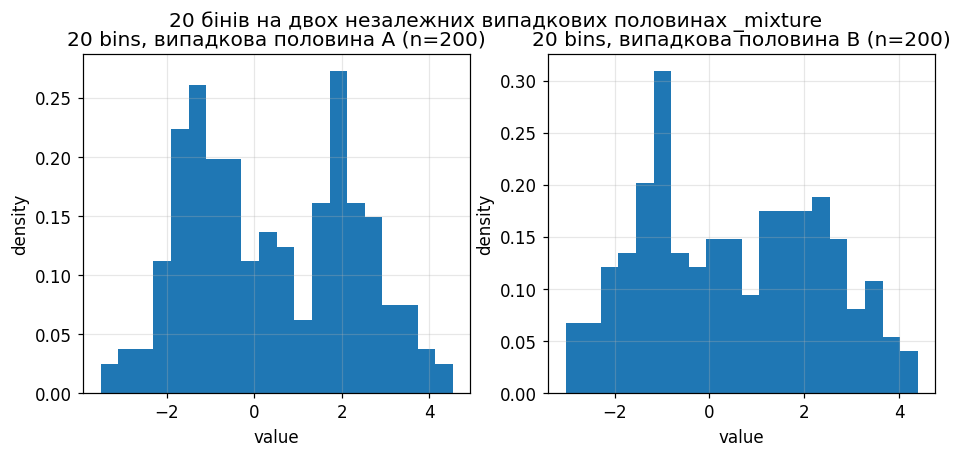

bins=20: кореляція висот стовпчиків між половинами = 0.739, порожніх бінів у половині A: 0 з 20


In [26]:
# (b) та сама форма, інша шкала y — порівняння density=True проти density=False
fig_density, axes_density = histogram_grid(_mixture, [5, 20, 200], density=True)
fig_counts, axes_counts = histogram_grid(_mixture, [5, 20, 200], density=False)
plt.show()

# числа для (b): висота найвищого стовпчика в обох режимах і площа під гістограмою
for bins in (5, 20, 200):
    counts, edges = np.histogram(_mixture, bins=bins)
    dens, _ = np.histogram(_mixture, bins=bins, density=True)
    width = edges[1] - edges[0]
    print(f"bins={bins:>3}: max count={counts.max():>3}  max density={dens.max():.4f}  "
          f"count/(N*width)={counts.max() / (len(_mixture) * width):.4f}  "
          f"площа density={np.sum(dens * np.diff(edges)):.3f}")

print("висоти 5 бінів (density):", np.round(np.histogram(_mixture, bins=5, density=True)[0], 3))

# (a)/(c) перевірка стійкості. УВАГА: _mixture — це дві компоненти, склеєні підряд
# (перші 200 точок — N(-1,1), наступні 200 — N(+2,1)), тож "перша/друга половина"
# за індексом дала б дві РІЗНІ компоненти. Тому спершу випадково перемішуємо індекси
# і лише потім ділимо: дві половини стають незалежними вибірками з тієї самої суміші.
_perm = np.random.default_rng(SEED).permutation(len(_mixture))
first_half, second_half = _mixture[_perm[:200]], _mixture[_perm[200:]]

for bins in (200, 20):
    fig_h, axes_h = plt.subplots(1, 2, figsize=(10, 4))
    for ax, half_sample, label in zip(axes_h, (first_half, second_half),
                                      ("випадкова половина A", "випадкова половина B")):
        ax.hist(half_sample, bins=bins, density=True)
        ax.set_xlabel("value")
        ax.set_ylabel("density")
        ax.set_title(f"{bins} bins, {label} (n={len(half_sample)})")
    fig_h.suptitle(f"{bins} бінів на двох незалежних випадкових половинах _mixture")
    plt.show()

    # наскільки збігаються дві половини: кореляція висот стовпчиків на спільних межах бінів
    edges = np.linspace(_mixture.min(), _mixture.max(), bins + 1)
    ha, _ = np.histogram(first_half, bins=edges, density=True)
    hb, _ = np.histogram(second_half, bins=edges, density=True)
    print(f"bins={bins}: кореляція висот стовпчиків між половинами = {np.corrcoef(ha, hb)[0, 1]:.3f}, "
          f"порожніх бінів у половині A: {(ha == 0).sum()} з {bins}")

**Your answer:**

**(a)** На **20 бінах** двокомпонентна структура видна чітко: дві вершини біля −1 і +2 з провалом між ними. На **5 бінах** вона лише вгадується і фактично прихована: п'ять широких стовпчиків з висотами 0.056, 0.205, 0.123, 0.178, 0.059 (вивід вище), тобто дві вищі смуги з нижчою між ними, але з такої картинки не видно ні положення піків, ні того, що це дві окремі гладкі компоненти, а не, скажімо, одна широка пласка. На **200 бінах** структуру ховає шум: на біні в середньому 2 точки, найвищий стовпчик — усього 8 точок, і дрібні «піки» — це пуассонівський шум підрахунку, а не реальна форма. Це я перевірив прямо: розділив `_mixture` на дві **випадкові** половини по 200 точок і порівняв їхні гістограми на спільних межах бінів. На 200 бінах кореляція висот стовпчиків між половинами лише 0.14, і в половині A 83 зі 200 бінів порожні: дрібні піки не відтворюються. На 20 бінах кореляція 0.74: обидві половини показують ту саму двогорбу форму. Отже, реальні лише два широкі горби; окремі голки на 200 бінах — ні. (Важлива деталь: `_mixture` — це дві компоненти, склеєні підряд, тому поділ «перші 200 / другі 200» за індексом дав би дві різні компоненти замість двох вибірок з однієї суміші. Спершу треба перемішати.)

**(b)** При `density=False` на осі y — сирі кількості точок у біні. Вони пропорційні розміру вибірки N і ширині біна: найвищий стовпчик на 5 бінах містить 132 точки, на 20 — 39, на 200 — 8. При `density=True` кожен лічильник ділиться на **N × ширина біна**: ті самі стовпчики мають висоти 0.2048, 0.2421 і 0.4966, а я перевірив, що 132 / (400 × ширина) дає рівно 0.2048. Площа під кожною density-гістограмою дорівнює 1.000 — тепер це оцінка густини ймовірності, а не підрахунок. Форми ідентичні, змінюється лише шкала. Тому `density=True` робить порівнюваними дві вибірки різного розміру: без нормалізації вибірка зі 100 000 точок завжди виглядала б «вищою» за вибірку з 1 000 точок, навіть якби обидві мали той самий розподіл.

**(c)** Перше питання: «Скільки бінів ви взяли — і чи лишається подвійний пік, якщо спробувати кілька інших розумних значень?» З (a) видно, що форма, побачена лише на одному довільному bin count, може бути артефактом розбиття (як голки на 200 бінах). Висновок про дві підгрупи має спиратися на структуру, стійку до зміни кількості бінів і до повторної вибірки, а в ідеалі — на незалежне пояснення, звідки взялися дві підгрупи.

## 12. Task 11 — Open-ended

No assert. This one is marked on the written analysis.

You are given a sample of 5000 measurements below, produced by a generator
whose parameters you are not told. Your task is to **characterise it and
say what you would do with the extreme values**, using only the tools from
Practice 1.

Work through at least the following, and write up what you find:

1. Describe the array: shape, dtype, how much memory it occupies.
2. Compute the mean, the median, the standard deviation, the minimum and
   the maximum. The mean and the median differ noticeably. What does that
   tell you before you have plotted anything?
3. Plot it as a histogram. Choose the bin count deliberately and justify
   your choice in one sentence.
4. Apply the k-sigma rule from Task 5 at k = 3. How many points are
   flagged? Compare that count with the roughly 0.27 % you would expect
   from a normal sample of this size.
5. Now the judgement. Recompute the mean and standard deviation **with the
   flagged points removed**. Report both versions. Then argue, in a
   paragraph, whether the flagged points should be removed — and be
   explicit about what you would need to know about *how the data was
   measured* before you could answer that with any confidence.

A good answer treats step 5 as a question about the measurement process,
not about the numbers. A weak answer deletes the outliers because a rule
said so.

In [27]:
# The data. Do not modify this cell.
_hidden_rng = np.random.default_rng(31337)
mystery_sample = np.concatenate([
    _hidden_rng.normal(10.0, 2.0, 4_900),
    _hidden_rng.uniform(25.0, 60.0, 100),
])
_hidden_rng.shuffle(mystery_sample)

print("mystery_sample is ready:", mystery_sample.shape)

mystery_sample is ready: (5000,)


shape: (5000,)  dtype: float64  пам'ять: 40000 байт = 8 байт x 5000
mean=10.631  median=10.092  std=5.066  min=2.572  max=59.728
Q1=8.654  Q3=11.479


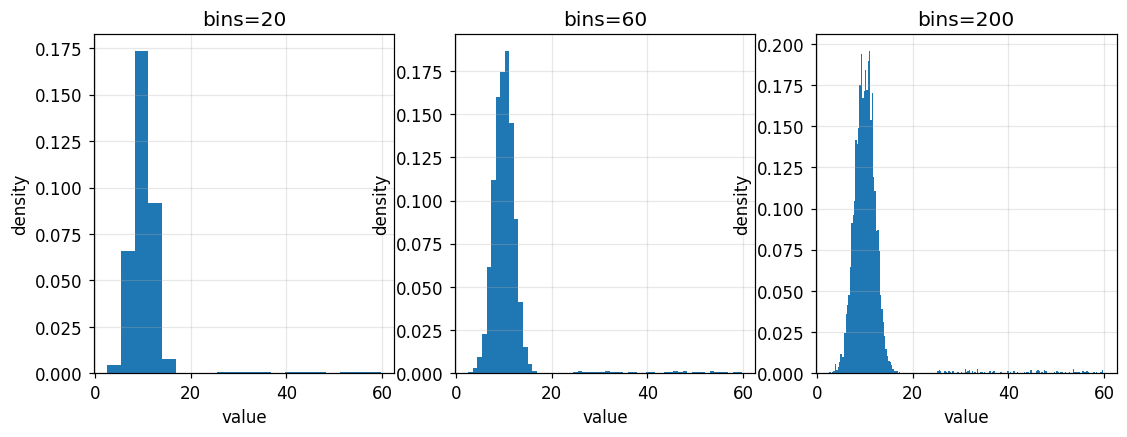


3-sigma: позначено 94 з 5000 (1.88%), межі [-4.566, 25.828]
для нормальної вибірки такого розміру очікувалося б ~13.5 точки (0.27%) -> у 7.0 раза більше

з усіма точками:          n=5000  mean=10.631  std=5.066
без 94 позначених:    n=4906  mean=10.021  std=2.093

хвіст (>= 20.0): n=100  min=25.241  max=59.728
ядро  (<  20.0): n=4900  mean=10.002  std=2.023
точок хвоста, які 3σ-правило НЕ позначило: 6
повторне 3σ на вже очищеній вибірці позначає ще 15 точок


In [28]:
# --- 1. Опис масиву ---
print("shape:", mystery_sample.shape, " dtype:", mystery_sample.dtype,
      " пам'ять:", mystery_sample.nbytes, "байт =", mystery_sample.itemsize, "байт x", mystery_sample.size)

# --- 2. Базовий числовий опис (без pandas — його тут не імпортовано) ---
mean = mystery_sample.mean()
std = mystery_sample.std(ddof=1)
median = np.median(mystery_sample)
print(f"mean={mean:.3f}  median={median:.3f}  std={std:.3f}  "
      f"min={mystery_sample.min():.3f}  max={mystery_sample.max():.3f}")
q1, q3 = np.percentile(mystery_sample, [25, 75])
print(f"Q1={q1:.3f}  Q3={q3:.3f}")

# --- 3. Гістограма. 60 бінів: на 5000 точках це ~80 точок на бін у ядрі (стабільна форма),
#        але біни вужчі за 1 одиницю, тож розрив між ядром і хвостом не замазується ---
fig, axes = histogram_grid(mystery_sample, [20, 60, 200], density=True)
plt.show()

# --- 4. k-sigma правило з Task 5 при k=3 ---
mask3, values3 = sigma_outliers(mystery_sample, k=3.0)
expected = 0.0027 * mystery_sample.size
print(f"\n3-sigma: позначено {mask3.sum()} з {mystery_sample.size} ({100 * mask3.mean():.2f}%), "
      f"межі [{mean - 3*std:.3f}, {mean + 3*std:.3f}]")
print(f"для нормальної вибірки такого розміру очікувалося б ~{expected:.1f} точки (0.27%) -> "
      f"у {mask3.sum() / expected:.1f} раза більше")

# --- 5. Перерахунок без позначених точок ---
kept = mystery_sample[~mask3]
print(f"\nз усіма точками:          n={mystery_sample.size}  mean={mean:.3f}  std={std:.3f}")
print(f"без {mask3.sum()} позначених:    n={kept.size}  mean={kept.mean():.3f}  std={kept.std(ddof=1):.3f}")

# --- Додатково: чи всі точки хвоста потрапили під 3σ (ефект маскування) ---
gap_threshold = 20.0   # за видимим на гістограмі розривом
tail = mystery_sample[mystery_sample >= gap_threshold]
core = mystery_sample[mystery_sample < gap_threshold]
print(f"\nхвіст (>= {gap_threshold}): n={tail.size}  min={tail.min():.3f}  max={tail.max():.3f}")
print(f"ядро  (<  {gap_threshold}): n={core.size}  mean={core.mean():.3f}  std={core.std(ddof=1):.3f}")
print(f"точок хвоста, які 3σ-правило НЕ позначило: {int((tail < mean + 3*std).sum())}")
mask3_core, _ = sigma_outliers(kept, k=3.0)
print(f"повторне 3σ на вже очищеній вибірці позначає ще {mask3_core.sum()} точок")

**Your write-up:**

**1. Масив.** `mystery_sample` має форму (5000,), dtype `float64`, займає 40 000 байт (8 байт × 5000 значень).

**2. Зведення.** mean = 10.631, median = 10.092, std = 5.066, min = 2.572, max = 59.728. Середнє помітно більше за медіану ще до будь-якого графіка — це вказує на правосторонню асиметрію: невелика кількість дуже великих значень тягне середнє вгору, а медіана до них байдужа. Друга підказка — сам std: IQR лише 2.83 (Q1 = 8.65, Q3 = 11.48), а std майже вдвічі більший. Для нормального розподілу std ≈ IQR/1.35 ≈ 2.1, тож std роздутий кількома віддаленими значеннями.

**3. Гістограма.** Основний вибір — 60 бінів: на 5000 точках це близько 80 точок на бін у ядрі (форма стабільна), а бін вужчий за одну одиницю, тож розрив між ядром і хвостом не замазується. Видно щільне, схоже на нормальне ядро з центром біля 10, далі порожню зону і пласку низьку «полицю» значень від ~25 до ~60. Ця полиця не спадає, як спадав би хвіст нормального розподілу, а має майже рівну висоту. Схоже, що це окреме джерело значень, а не хвіст того самого розподілу.

**4. 3σ-правило.** При k = 3 позначено **94 точки з 5000 (1.88%)**, межі [−4.57, 25.83]. Для нормальної вибірки такого розміру очікувалося б 0.27%, тобто ≈13.5 точки — у мене в 7 разів більше. Отже, це не рідкісні хвости одного нормального розподілу. Водночас правило пропустило частину хвоста: з точок полиці (≥ 20; їх 100, мінімум 25.24) шість лежать нижче верхньої межі 25.83 і не позначені. Причина — **маскування**: std, за яким будується поріг, уже роздутий тими самими далекими точками, тож поріг піднявся й частину з них сховав.

**5. Рішення.**

| | n | mean | std |
|---|---|---|---|
| усі точки | 5000 | 10.631 | 5.066 |
| без 94 позначених | 4906 | 10.021 | 2.093 |

Видалення 1.9% точок зсуває середнє на 0.6 і зменшує std у 2.4 раза. Отже, від цього рішення залежить майже кожен наступний висновок, і приймати його за самим фактом спрацювання правила не можна. Правило ще й нестабільне: якщо застосувати 3σ повторно до вже очищеної вибірки, воно позначає ще 15 точок, бо поріг звужується разом зі std.

Чи видаляти ці точки — питання не до чисел, а до **процесу вимірювання**. Форма даних показує лише одне: є два механізми, основний (≈98%, близько 10 ± 2) і рідкісний (≈2%, приблизно рівномірно від 25 до 60). Вона не каже, котрий із них помилка. Перш ніж вирішувати, мені потрібно знати:

- що саме вимірюється і чи фізично можливі значення 25–60 (наприклад, чи прилад має такий діапазон);
- чи збігаються ці значення в часі з відомими збоями: перезапуском приладу, зміною оператора, іншою партією чи іншим датчиком;
- чи мають записи з полиці спільну мітку в метаданих (джерело, прилад, час);
- чи досліджуване питання стосується саме типового значення, чи рідкісних великих подій, для яких полиця і є найцікавішою частиною даних.

Якщо з'ясується, що це збій приладу (наприклад, датчик у режимі помилки видає випадкове число з усього діапазону), ці точки варто прибрати, і тоді правильна оцінка — ядро, mean ≈ 10.0, std ≈ 2.0. Якщо ж це реальні рідкісні події, їх видалення підмінило б дослідження зручнішою картинкою. Тоді дані треба описувати як суміш і повідомляти обидві групи окремо. До отримання цієї інформації я не видаляв би точки, а звітував би обидва рядки таблиці вище з прямою приміткою, що 2% спостережень належать до окремої групи невідомого походження.

## 13. Before you submit

- Runtime → **Restart and run all**. Every cell must execute in order with
  no error and every assert must pass.
- Every written question has an answer that refers to numbers you actually
  produced.
- Task 11 has a written conclusion, not only code.